# 📊 Exploratory Data Analysis (EDA) Plan

*Statistical Characterization of the PTB-XL Dataset*

---

## 🎯 Objectives of EDA

The purpose of EDA is to:

1. Understand population characteristics
2. Quantify label distribution and imbalance
3. Assess signal properties
4. Identify potential sources of bias
5. Inform modeling and validation strategy

EDA is not visualization for aesthetics — it is **pre-model statistical reconnaissance**.

---

# 1️⃣ Cohort Characterization

## 1.1 Sample Size

* Total number of ECG recordings
* Total number of unique patients
* Recordings per patient distribution

**Why it matters:**
Prevents patient-level data leakage and informs split strategy.

---

## 1.2 Demographics

### Age

* Mean ± SD
* Median (IQR)
* Histogram
* Age bins (e.g., <40, 40–60, >60)

### Sex

* Counts and percentages
* Bar plot

**Why it matters:**
Enables subgroup analysis and bias assessment.

---

# 2️⃣ Label Distribution Analysis

PTB-XL is multi-label.

## 2.1 Diagnostic Superclasses

Compute:

* Count per class
* Prevalence (%)
* Co-occurrence matrix

Display:

* Bar plot of class frequencies
* Heatmap of label co-occurrence

**Why it matters:**

* Detects severe imbalance
* Guides weighted loss design
* Informs macro vs micro metric choice

---

## 2.2 Label Cardinality

* Average number of labels per ECG
* Distribution of label counts

This tells you:

* How multi-label the dataset actually is

---

# 3️⃣ Signal-Level Analysis

(Using 500 Hz or 100 Hz data)

## 3.1 Signal Length

* Confirm uniform length
* Check for missing or corrupted files

## 3.2 Amplitude Distribution

* Mean amplitude per lead
* Standard deviation per lead
* Outlier detection

## 3.3 Lead Correlation

* Correlation matrix between leads
* Detect redundancy or abnormal signals

---

# 4️⃣ Missingness Analysis

* Missing demographic data
* Missing labels
* Missing signals

If present:

* Quantify proportion
* Determine missingness pattern (MCAR/MAR suspicion)

---

# 5️⃣ Train/Test Split Validation

Before training:

* Confirm patient-level split
* Compare:

  * Age distribution (train vs test)
  * Sex distribution
  * Label prevalence

Use:

* t-test or Mann–Whitney (age)
* Chi-square test (sex, labels)

**Goal:** Ensure no distributional shift between splits.

---

# 6️⃣ Class Imbalance Quantification

Compute:

* Imbalance ratio (max/min class frequency)
* Effective number of samples (for weighted loss)

Decide:

* Class weights
* Focal loss?
* Threshold tuning strategy?

---

# 7️⃣ Correlation Between Demographics and Labels

Example analyses:

* Age vs MI prevalence
* Sex vs conduction disorders

Use:

* Logistic regression (univariate)
* Odds ratios with 95% CI

This gives you publishable-level descriptive stats.

---

# 📈 Key Tables to Produce

| Table   | Description                           |
| ------- | ------------------------------------- |
| Table 1 | Baseline Demographics                 |
| Table 2 | Diagnostic Class Prevalence           |
| Table 3 | Label Co-occurrence Matrix            |
| Table 4 | Train vs Test Distribution Comparison |

---

# 🧠 Statistical Framing

EDA is answering:

* Is the dataset representative?
* Is it balanced?
* Is it suitable for macro-AUC evaluation?
* Are there confounders?
* Will subgroup analysis be powered?

---

# 🚨 Red Flags to Look For

* Extreme class imbalance (<1%)
* One sex dominating a diagnostic label
* Age skew in test set
* Highly correlated labels
* Duplicate patients across splits

In [1]:
# --------------------------------------------------
# Importing necessary libraries
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
import wfdb

## 1️⃣ Load the Data

In [2]:
# --------------------------------------------------
# Setting up paths
# --------------------------------------------------
file_path = "../data/ptbxl_database.csv"
df = pd.read_csv(file_path, sep=",", index_col='ecg_id')

# print basic info about the dataframe
print(df.info())
print(df.describe())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
Index: 21799 entries, 1 to 21837
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    21799 non-null  float64
 1   age                           21799 non-null  float64
 2   sex                           21799 non-null  int64  
 3   height                        6974 non-null   float64
 4   weight                        9421 non-null   float64
 5   nurse                         20326 non-null  float64
 6   site                          21782 non-null  float64
 7   device                        21799 non-null  object 
 8   recording_date                21799 non-null  object 
 9   report                        21799 non-null  object 
 10  scp_codes                     21799 non-null  object 
 11  heart_axis                    13331 non-null  object 
 12  infarction_stadium1           5612 non-null   object 
 13  infarc

In [3]:
df.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


# 2️⃣ Diagnostic Labels

The diagnostic Labels are in a format where more than 1 condition can be present based on the ECG and cardiologist interpretation. These classifications are the scp codes. The possible scp codes are `['NORM','MI','STTC','CD','HYP']`. These are the five major dignostic superclasses used to classify ECG signals. 
* NORM: Normal ECG
* MI (Myocardial Infarction): Indicates heart attacks. 
* STTC (ST/T Change): Indicates abnormalitioes in the ST segment or the T wave. 
* CD (Conduction Disturbance): Disturbances in the heart's electrical conduction system.
* HYP (Hypertrophy): Enlargement of the heart muscle. 

Source: [PubMed, Deep Learning Models for Arrhythmia Classification Based on ECG Signals Using PTB-X Dataset](https://pmc.ncbi.nlm.nih.gov/articles/PMC12346745/)

Need to encode these classifications which act as our ground truth through Multilabel Encoder.

In [4]:
# -- 2. Load SCP statements & filter to diagnostic only --
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Load SCP statements to get superclass mappings
agg_df = pd.read_csv('../data/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

# -- 3. Map SCP Codes -> Diagnostic superclass
def get_superclass(scp_dict):
    classes = []
    # Loop through the scp_dict for an ECG interpretation
    for key in scp_dict.keys():
        # Add present SCP codes under a new column called diagnostic_class and store it into classes 
        if key in agg_df.index:
            classes.append(agg_df.loc[key, 'diagnostic_class'])
    return list(set(classes))

df['superclass'] = df['scp_codes'].apply(get_superclass)
df = df[df['superclass'].map(len) > 0]  # drop records with no diagnostic label

print(df['superclass'].value_counts())

superclass
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[CD, MI]               1297
[HYP, STTC]             781
[STTC, MI]              599
[HYP]                   535
[CD, NORM]              407
[HYP, STTC, MI]         361
[HYP, CD]               300
[CD, STTC]              270
[STTC, CD]              201
[HYP, MI]               183
[HYP, STTC, CD]         127
[CD, STTC, MI]          118
[HYP, CD, MI]           117
[STTC, CD, MI]          105
[HYP, STTC, CD, MI]     103
[HYP, CD, STTC]          84
[HYP, CD, STTC, MI]      53
[STTC, NORM]             28
[STTC, CD, NORM]          5
[HYP, CD, NORM]           2
[HYP, NORM]               2
[HYP, CD, NORM, MI]       1
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import MultiLabelBinarizer
# -- 4. Apply Multilabel Binarizer --

# Encode the SCP codes where 1 indictaes condition is present and 0 indictes it is not
mlb = MultiLabelBinarizer(classes=['NORM','MI','STTC','CD','HYP'])
Y = mlb.fit_transform(df['superclass']) # The shape should be (N, 5)
print(Y.shape)

(21388, 5)


In [6]:
# ---------------------------------------------------
# Sanity Checks on the extracted superclasses
# ---------------------------------------------------

# Check how many ECGs have at least one diagnostic label
n_with_labels = (df["superclass"].apply(len) > 0).sum()
n_total = len(df)

print(f"ECGs with diagnostic labels: {n_with_labels}/{n_total}")
print(f"Percentage labeled: {100 * n_with_labels / n_total:.2f}%")

# Check for empty labels
empty_labels = df[df["superclass"].apply(len) == 0]
print("Number of ECGs with NO diagnostic superclass:", len(empty_labels))

ECGs with diagnostic labels: 21388/21388
Percentage labeled: 100.00%
Number of ECGs with NO diagnostic superclass: 0


In [7]:
# Count the occurrences of each superclass
all_classes = [cls for sublist in df["superclass"] for cls in sublist]
class_counts = pd.Series(all_classes).value_counts()

print("\nDiagnostic Superclass Counts:")
print(class_counts)


Diagnostic Superclass Counts:
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64


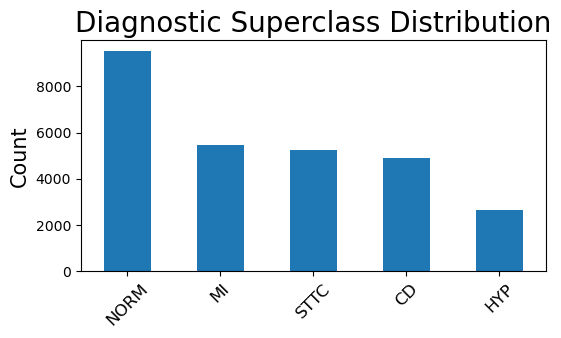

In [8]:
# -- Make a figure showing the Superclass Distributions --
plt.figure(figsize=(6, 3), facecolor='white')

# Define fontsizes
label = 15 
title = 20 
ticks = 12

# Plot class_counts
class_counts.plot(kind="bar")
plt.title("Diagnostic Superclass Distribution", fontsize=title)
plt.ylabel("Count", fontsize=label)
plt.xticks(rotation=45, fontsize=ticks)
plt.show()

## Generate Table 1 Summary Statistics

In [45]:
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']  # module-level constant

def cohort_summary_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate a Table 1 cohort summary for the PTB-XL dataset.

    Args:
        df (pd.DataFrame): Dataframe containing 'patient_id', 'age', 'sex',
                           and 'superclass' columns.

    Returns:
        pd.DataFrame: Summary table with columns ['Characteristic', 'Value'].
    """
    df = df.copy()  # never mutate the caller's dataframe

    # -- Cohort size --
    n_records  = df.shape[0]
    n_patients = df['patient_id'].nunique()

    # -- Age --
    # Correct HIPAA-compliant encoding: age > 89 stored as 300 in PTB-XL
    df.loc[df['age'] >= 89, 'age'] = 90

    age_mean   = df['age'].mean()
    age_sd     = df['age'].std(ddof=1)  # explicit: sample standard deviation
    age_median = df['age'].median()
    age_q1     = df['age'].quantile(0.25)
    age_q3     = df['age'].quantile(0.75)

    # -- Sex --
    # PTB-XL encodes 0 = Female, 1 = Male
    sex_counts  = (df['sex']
                   .value_counts()
                   .rename({0: 'Female', 1: 'Male'})
                   .reindex(['Female', 'Male'], fill_value=0))  # explicit order, safe if one sex missing
    sex_percent = sex_counts / n_records * 100

    # -- Diagnostic superclasses --
    # Multi-label: % = records containing this class / total records
    all_classes   = [cls for sublist in df['superclass'] for cls in sublist]
    class_counts  = (pd.Series(all_classes)
                     .value_counts()
                     .reindex(CLASS_ORDER, fill_value=0))  # consistent clinical order
    class_percent = class_counts / n_records * 100

    # -- Build table --
    rows = []

    rows.append(["Total ECG Recordings", f"{n_records:,}"])
    rows.append(["Unique Patients",       f"{n_patients:,}"])
    rows.append(["Age (years), mean ± SD",
                 f"{age_mean:.1f} ± {age_sd:.1f}"])
    rows.append(["Age (years), median (IQR)",
                 f"{age_median:.1f} ({age_q1:.1f}–{age_q3:.1f})"])

    for sex in sex_counts.index:
        rows.append([f"Sex: {sex}",
                     f"{sex_counts[sex]:,} ({sex_percent[sex]:.1f}%)"])

    for cls in class_counts.index:
        rows.append([f"Diagnosis: {cls}",
                     f"{class_counts[cls]:,} ({class_percent[cls]:.1f}%)"])

    return pd.DataFrame(rows, columns=["Characteristic", "Value"])
# -----------------------------------------------------------------------------------------------------------------------------------
def plot_cohort_summary_stats(df: pd.DataFrame) -> dict:
    """
    Visualize cohort-level summary statistics.
    Companion plotting function to cohort_summary_stats().

    Args:
        df (pd.DataFrame): Raw dataframe containing 'age', 'sex',
                           and 'superclass' columns.

    Returns:
        dict: Dictionary of matplotlib figures keyed by plot name.
    """
    cohort_plots = {}

    df = df.copy()
    df.loc[df['age'] >= 89, 'age'] = 90
    df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})

    n_records   = len(df)
    SEX_PALETTE = {'Female': '#D4537E', 'Male': '#378ADD'}

    # ── 1. Age histogram with KDE ─────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(9, 4))
    sns.histplot(
        data=df, x='age', bins=30,
        color='#378ADD', alpha=0.6,
        kde=True, line_kws={'linewidth': 2},
        ax=ax1
    )
    ax1.axvline(df['age'].median(), color='#D4537E', linewidth=1.5,
                linestyle='--', label=f"Median: {df['age'].median():.0f} yrs")
    ax1.set_title('Age distribution — full cohort', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Age (years)')
    ax1.set_ylabel('Number of records')
    ax1.legend()
    sns.despine(ax=ax1)
    fig1.tight_layout()
    cohort_plots['age_histogram'] = fig1

    # ── 2. Sex distribution bar ───────────────────────────────────────────────
    sex_counts  = df['sex_label'].value_counts().reindex(['Female', 'Male'], fill_value=0)
    sex_percent = sex_counts / n_records * 100

    fig2, ax2 = plt.subplots(figsize=(5, 4))
    bars = ax2.bar(
        sex_counts.index, sex_counts.values,
        color=[SEX_PALETTE[s] for s in sex_counts.index],
        edgecolor='none', width=0.5
    )
    for bar, (label, count) in zip(bars, sex_counts.items()):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 80,
                 f'{count:,}\n({sex_percent[label]:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
    ax2.set_title('Sex distribution — full cohort', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Number of records')
    ax2.set_ylim(0, sex_counts.max() * 1.2)
    sns.despine(ax=ax2)
    fig2.tight_layout()
    cohort_plots['sex_bar'] = fig2

    # ── 3. Diagnosis prevalence horizontal bar ────────────────────────────────
    all_classes  = [cls for sublist in df['superclass'] for cls in sublist]
    class_counts = (pd.Series(all_classes)
                    .value_counts()
                    .reindex(CLASS_ORDER, fill_value=0))
    class_pct    = class_counts / n_records * 100

    COLORS = ['#378ADD', '#1D9E75', '#EF9F27', '#D4537E', '#7F77DD']

    fig3, ax3 = plt.subplots(figsize=(8, 4))
    bars = ax3.barh(
        class_counts.index, class_counts.values,
        color=COLORS, edgecolor='none', height=0.55
    )
    for bar, (cls, count) in zip(bars, class_counts.items()):
        ax3.text(bar.get_width() + 80,
                 bar.get_y() + bar.get_height() / 2,
                 f'{count:,}  ({class_pct[cls]:.1f}%)',
                 va='center', fontsize=10)
    ax3.set_xlabel('Number of records')
    ax3.set_title('Diagnosis prevalence — full cohort\n(multi-label: % of total records)',
                  fontsize=13, fontweight='bold')
    ax3.set_xlim(0, class_counts.max() * 1.25)
    sns.despine(ax=ax3)
    fig3.tight_layout()
    cohort_plots['diagnosis_prevalence'] = fig3

    # ── 4. Age distribution by sex (overlapping KDE) ──────────────────────────
    fig4, ax4 = plt.subplots(figsize=(9, 4))
    for sex, color in SEX_PALETTE.items():
        subset = df[df['sex_label'] == sex]
        sns.kdeplot(
            data=subset, x='age',
            color=color, linewidth=2,
            fill=True, alpha=0.25,
            label=f"{sex} (n={len(subset):,})",
            ax=ax4
        )
    ax4.set_title('Age distribution by sex — full cohort', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Age (years)')
    ax4.set_ylabel('Density')
    ax4.legend(title='Sex')
    sns.despine(ax=ax4)
    fig4.tight_layout()
    cohort_plots['age_by_sex_kde'] = fig4

    return cohort_plots

Split: GLOBAL  (21,388 records)


,Characteristic,Value
0,Total ECG Recordings,"21,388"
1,Unique Patients,"18,617"
2,"Age (years), mean ± SD",59.8 ± 17.0
3,"Age (years), median (IQR)",62.0 (50.0–72.0)
4,Sex: Female,"11,111 (51.9%)"
5,Sex: Male,"10,277 (48.1%)"
6,Diagnosis: NORM,"9,514 (44.5%)"
7,Diagnosis: MI,"5,469 (25.6%)"
8,Diagnosis: STTC,"5,235 (24.5%)"
9,Diagnosis: CD,"4,898 (22.9%)"




Split: TRAIN  (17,084 records)


,Characteristic,Value
0,Total ECG Recordings,"17,084"
1,Unique Patients,"14,823"
2,"Age (years), mean ± SD",59.6 ± 16.9
3,"Age (years), median (IQR)",61.0 (50.0–72.0)
4,Sex: Female,"8,887 (52.0%)"
5,Sex: Male,"8,197 (48.0%)"
6,Diagnosis: NORM,"7,596 (44.5%)"
7,Diagnosis: MI,"4,379 (25.6%)"
8,Diagnosis: STTC,"4,186 (24.5%)"
9,Diagnosis: CD,"3,907 (22.9%)"




Split: VAL  (2,146 records)


,Characteristic,Value
0,Total ECG Recordings,"2,146"
1,Unique Patients,"1,917"
2,"Age (years), mean ± SD",60.2 ± 17.5
3,"Age (years), median (IQR)",62.0 (49.2–73.0)
4,Sex: Female,"1,114 (51.9%)"
5,Sex: Male,"1,032 (48.1%)"
6,Diagnosis: NORM,955 (44.5%)
7,Diagnosis: MI,540 (25.2%)
8,Diagnosis: STTC,528 (24.6%)
9,Diagnosis: CD,495 (23.1%)




Split: TEST  (2,158 records)


,Characteristic,Value
0,Total ECG Recordings,"2,158"
1,Unique Patients,"1,877"
2,"Age (years), mean ± SD",60.9 ± 17.6
3,"Age (years), median (IQR)",63.0 (50.0–74.0)
4,Sex: Female,"1,110 (51.4%)"
5,Sex: Male,"1,048 (48.6%)"
6,Diagnosis: NORM,963 (44.6%)
7,Diagnosis: MI,550 (25.5%)
8,Diagnosis: STTC,521 (24.1%)
9,Diagnosis: CD,496 (23.0%)


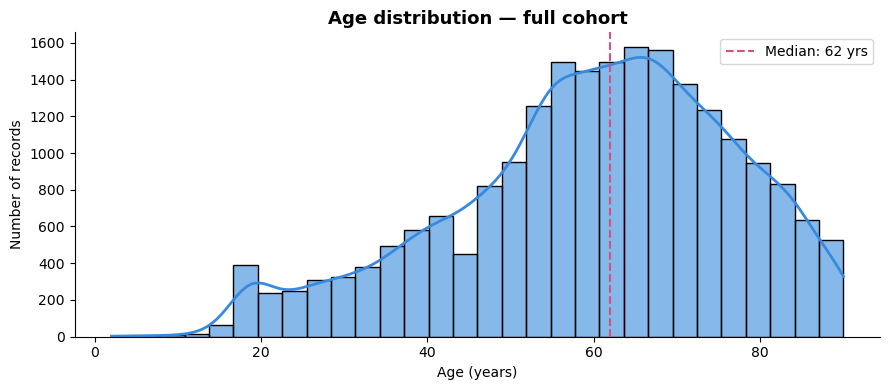

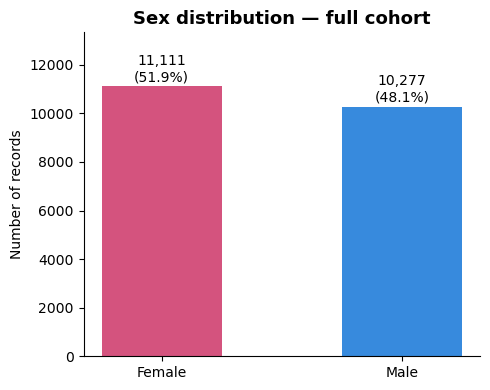

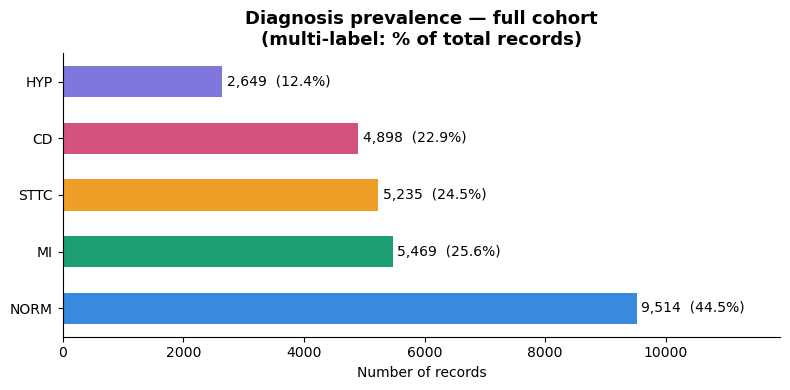

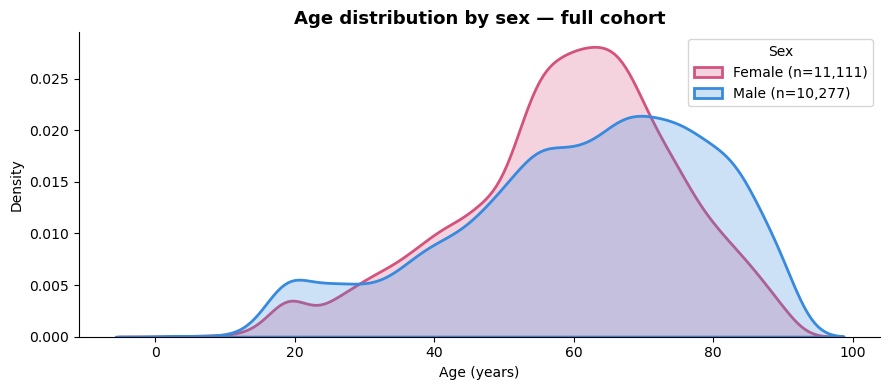

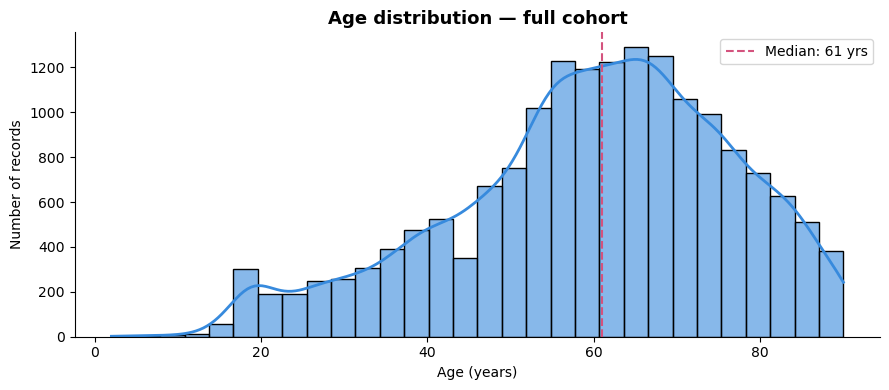

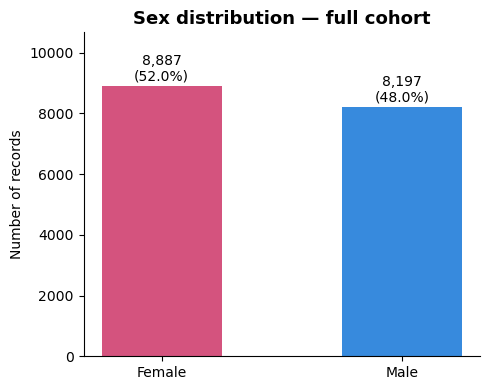

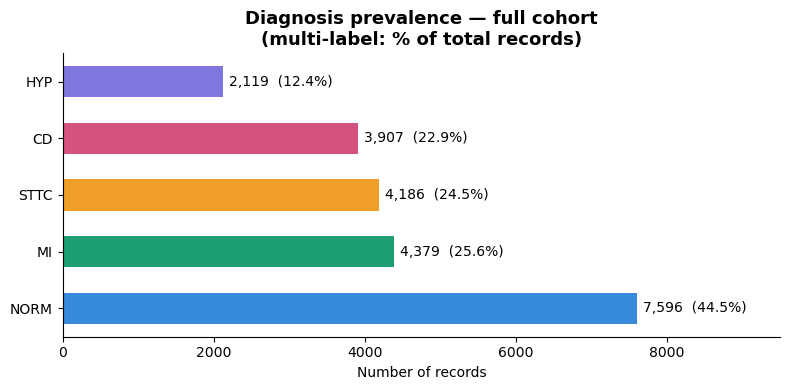

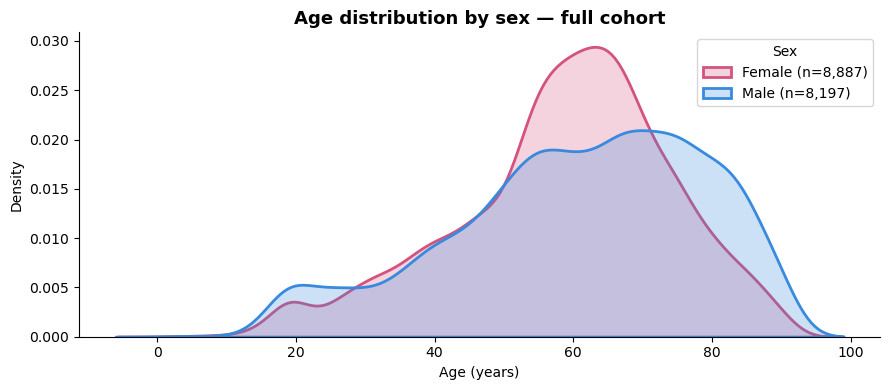

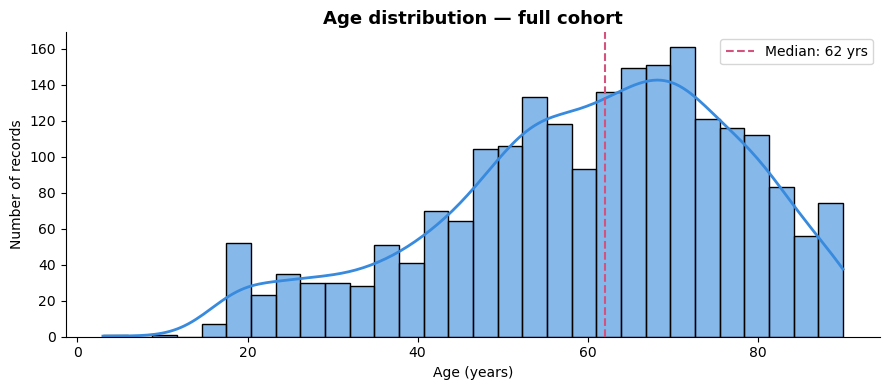

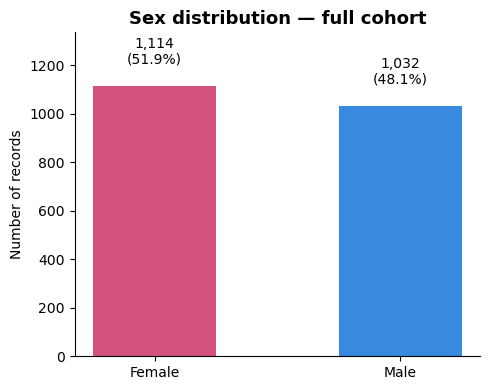

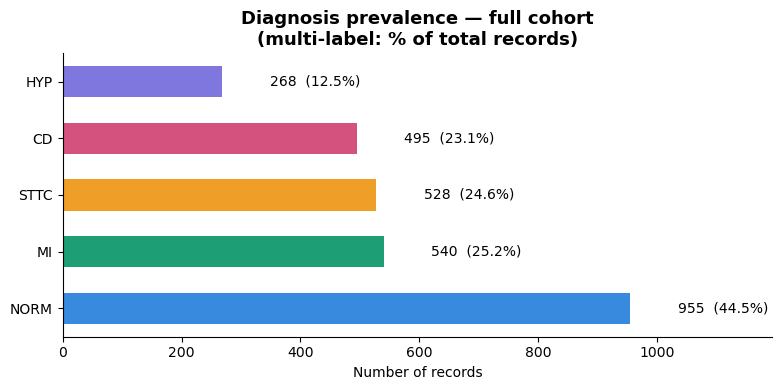

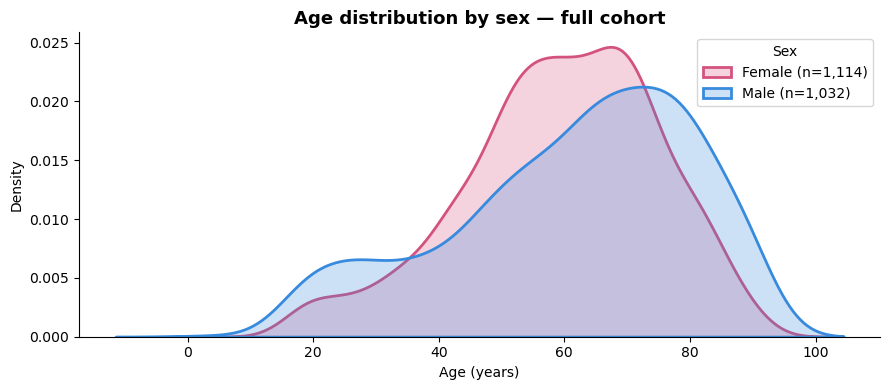

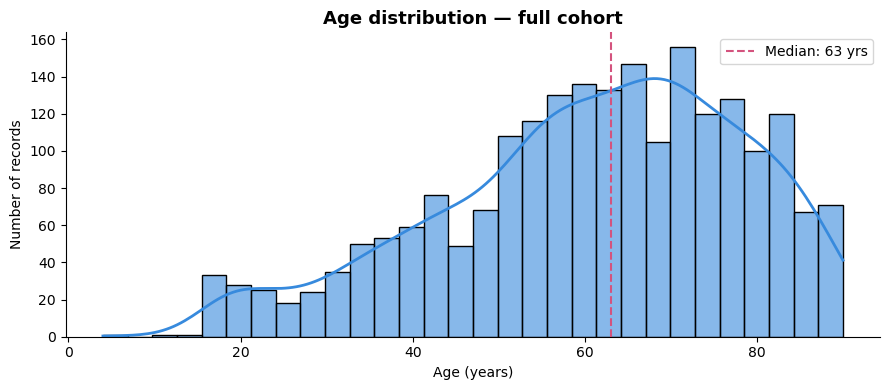

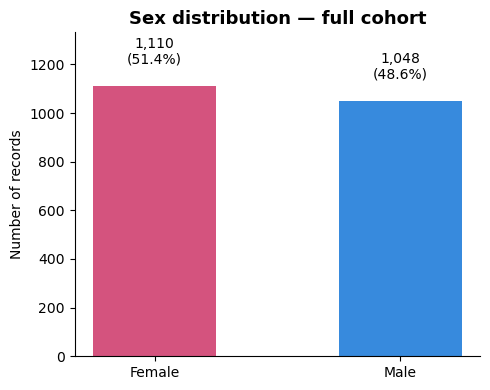

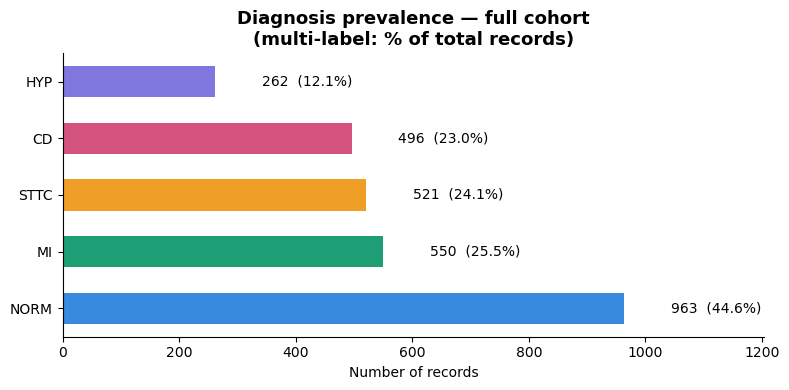

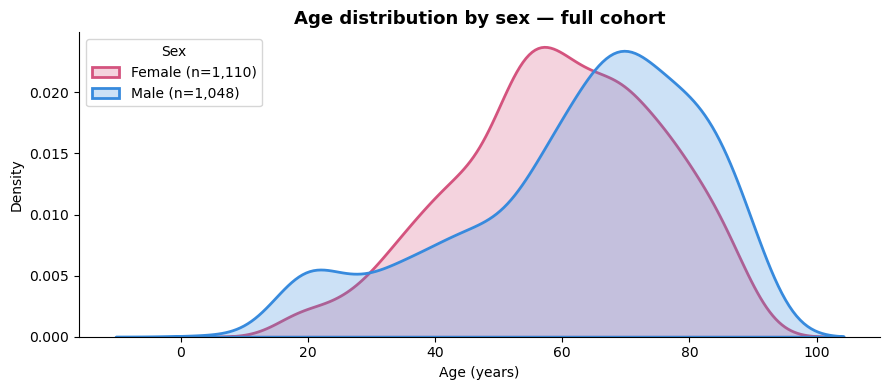

In [46]:
split_df = {
    'global': df,
    'train':  df[df['split'] == 'train'],
    'val':    df[df['split'] == 'val'],
    'test':   df[df['split'] == 'test'],
}

# ── Cohort summary stats + plots ──────────────────────────────────────────────
summary_tables = {}
cohort_plots   = {}

for key, df_split in split_df.items():
    print(f"{'='*60}")
    print(f"Split: {key.upper()}  ({len(df_split):,} records)")
    print(f"{'='*60}")

    summary_tables[key] = cohort_summary_stats(df_split)
    cohort_plots[key]   = plot_cohort_summary_stats(df_split)

    display(summary_tables[key])
    print("\n")

## Generate Table 2

In [39]:
def demographics_by_superclass(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute age and sex statistics stratified by diagnostic superclass.

    Args:
        df (pd.DataFrame): Dataframe containing 'superclass', 'age', and 'sex' columns.

    Returns:
        tuple:
            stats (pd.DataFrame): Formatted age and sex statistics per superclass.
            df_exploded (pd.DataFrame): Exploded dataframe used for downstream plotting.
    """
    df = df.copy()
    df.loc[df['age'] >= 89, 'age'] = 90

    # Explode so each row = one superclass label
    df_exploded = df[['patient_id', 'age', 'sex', 'superclass']].explode('superclass')
    df_exploded = df_exploded.dropna(subset=['superclass'])
    df_exploded['sex_label'] = df_exploded['sex'].map({0: 'Female', 1: 'Male'})  # must be here

    # Age statistics
    age_stats = (
        df_exploded.groupby('superclass')['age']
        .agg(
            mean_age='mean',
            sd_age='std',
            median_age='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            n='count'
        )
        .round(1)
    )

    # Sex statistics
    sex_stats = (
        df_exploded.groupby('superclass')['sex']
        .value_counts(normalize=True)
        .unstack()
        .reindex(columns=[0, 1], fill_value=0)  # 0 = Female, 1 = Male
        .rename(columns={0: 'female_pct', 1: 'male_pct'})
        .mul(100)
        .round(1)
    )

    # Sex counts (for the n in parentheses)
    sex_counts = (
        df_exploded.groupby('superclass')['sex']
        .value_counts()
        .unstack()
        .reindex(columns=[0, 1], fill_value=0)
        .rename(columns={0: 'female_n', 1: 'male_n'})
    )

    # Combine
    stats = age_stats.join(sex_stats).join(sex_counts)

    # Format columns
    stats['N (label count)'] = stats['n'].apply(lambda x: f"{x:,}")
    stats['Mean ± SD']       = stats.apply(lambda r: f"{r['mean_age']} ± {r['sd_age']}", axis=1)
    stats['Median (IQR)']    = stats.apply(lambda r: f"{r['median_age']} ({r['q1']}–{r['q3']})", axis=1)
    stats['Female']          = stats.apply(lambda r: f"{r['female_n']:,.0f} ({r['female_pct']}%)", axis=1)
    stats['Male']            = stats.apply(lambda r: f"{r['male_n']:,.0f} ({r['male_pct']}%)", axis=1)

    return stats[['N (label count)', 'Mean ± SD', 'Median (IQR)', 'Female', 'Male',
                  'female_pct', 'male_pct', 'n']], df_exploded

def plot_demographics_by_superclass(stats: pd.DataFrame, df_exploded: pd.DataFrame) -> dict:
    """
    Visualize demographics stratified by diagnostic superclass.
    Consumes outputs from demographics_by_superclass().

    Args:
        stats (pd.DataFrame): Formatted stats table from demographics_by_superclass().
        df_exploded (pd.DataFrame): Exploded dataframe from demographics_by_superclass().

    Returns:
        dict: Dictionary of matplotlib figures keyed by plot name.
    """
    demographic_stat_plots = {}

    # Define colors and orders
    CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
    COLORS      = ['#378ADD', '#1D9E75', '#EF9F27', '#D4537E', '#7F77DD']
    PALETTE     = dict(zip(CLASS_ORDER, COLORS))
    SEX_PALETTE = {'Female': '#D4537E', 'Male': '#378ADD'}
    
    # -- 1. Age Distribution by Superclass (Violin + Boxplot) --
    fig1, ax1 = plt.subplots(figsize=(10,5), facecolor='white')
    sns.violinplot(
        data=df_exploded, x='superclass', y='age', hue='superclass',
        order=CLASS_ORDER, palette=PALETTE,
        alpha=0.4, ax=ax1
    )
    sns.boxplot(
        data=df_exploded, x='superclass', y='age',
        order=CLASS_ORDER, width=0.15, 
        color='white', linewidth=1.2, 
        ax=ax1
    )
    ax1.set_title('Age distribution by diagnostic superclass', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Superclass'); ax1.set_ylabel('Age (years)')
    ax1.set_ylim(0, 95)
    sns.despine(ax=ax1)
    fig1.tight_layout()
    demographic_stat_plots['age_violin'] = fig1

    # -- 2. Sex breakdown by superclass (stacked horizontal bar) --
    sex_pct = (
        stats.reindex(CLASS_ORDER)[['female_pct', 'male_pct']]
        .rename(columns={'female_pct': 'Female', 'male_pct': 'Male'})
    )
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    sex_pct.plot(
        kind='barh', stacked=True,
        color=[SEX_PALETTE['Female'], SEX_PALETTE['Male']],
        ax=ax2, edgecolor='none'
    )
    ax2.axvline(50, color='white', linewidth=1.2, linestyle='--')
    ax2.set_xlabel('Percentage (%)'); ax2.set_ylabel('')
    ax2.set_title('Sex distribution by diagnostic superclass', fontsize=13, fontweight='bold')
    ax2.legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax2.set_xlim(0, 100)
    sns.despine(ax=ax2)
    fig2.tight_layout()
    demographic_stat_plots['sex_stacked_bar'] = fig2

    # -- 3. Record counts per superclass --
    counts = stats.reindex(CLASS_ORDER)['n']
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    bars = ax3.barh(CLASS_ORDER, counts.values, 
                    color=COLORS, edgecolor='none', height=0.55)
    for bar, val in zip(bars, counts.values):
        ax3.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=10)
    ax3.set_xlabel('Number of records (label count)')
    ax3.set_title('Record counts per diagnostic superclass', fontsize=13, fontweight='bold')
    ax3.set_xlim(0, counts.max() * 1.15)
    sns.despine(ax=ax3)
    fig3.tight_layout()
    demographic_stat_plots['class_counts'] = fig3

    # ── 4. Age × sex interaction per superclass (grouped boxplot) ─────────────
    fig4, ax4 = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=df_exploded, x='superclass', y='age', hue='sex_label',
        order=CLASS_ORDER, palette=SEX_PALETTE,
        width=0.5, fliersize=2, linewidth=1.0, ax=ax4
    )
    ax4.set_title('Age by superclass and sex', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Superclass'); ax4.set_ylabel('Age (years)')
    ax4.legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
    sns.despine(ax=ax4)
    fig4.tight_layout()
    demographic_stat_plots['age_sex_interaction'] = fig4

    return demographic_stat_plots

Split: global (21,388 records)
           N (label count)    Mean ± SD      Median (IQR)         Female  \
superclass                                                                 
CD                   4,898  66.0 ± 15.4  68.0 (57.0–77.0)  2,999 (61.2%)   
HYP                  2,649  66.4 ± 14.2  68.0 (58.0–77.0)  1,520 (57.4%)   
MI                   5,469  66.8 ± 12.9  67.0 (58.0–76.0)  3,407 (62.3%)   
NORM                 9,514  52.2 ± 17.3  54.0 (40.0–65.0)  4,386 (46.1%)   
STTC                 5,235  66.9 ± 13.9  68.0 (58.0–77.0)  2,566 (49.0%)   

                     Male  female_pct  male_pct     n  
superclass                                             
CD          1,899 (38.8%)        61.2      38.8  4898  
HYP         1,129 (42.6%)        57.4      42.6  2649  
MI          2,062 (37.7%)        62.3      37.7  5469  
NORM        5,128 (53.9%)        46.1      53.9  9514  
STTC        2,669 (51.0%)        49.0      51.0  5235  
____________________________________________

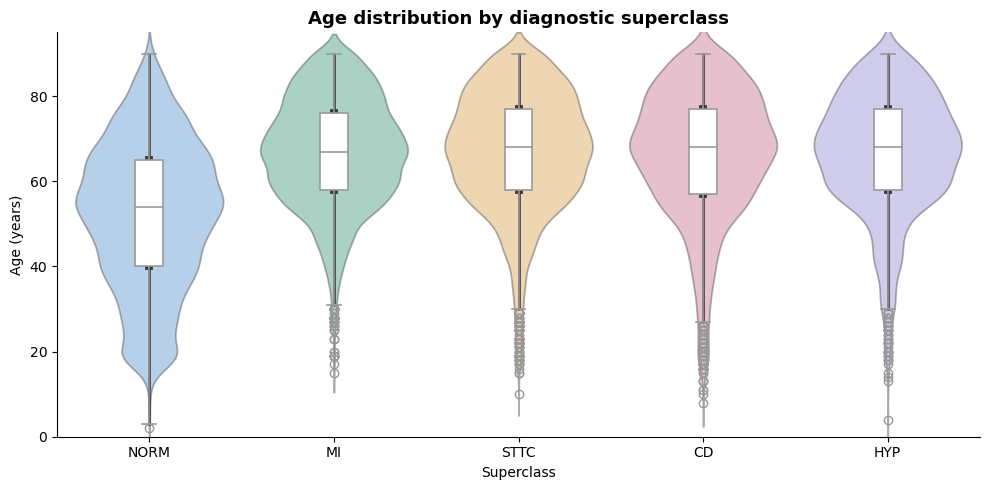

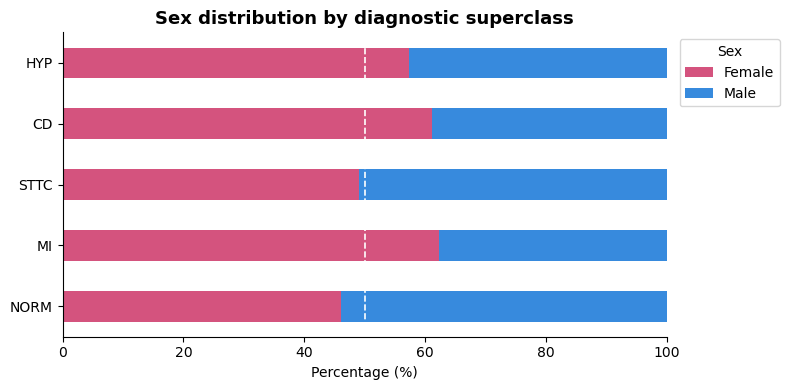

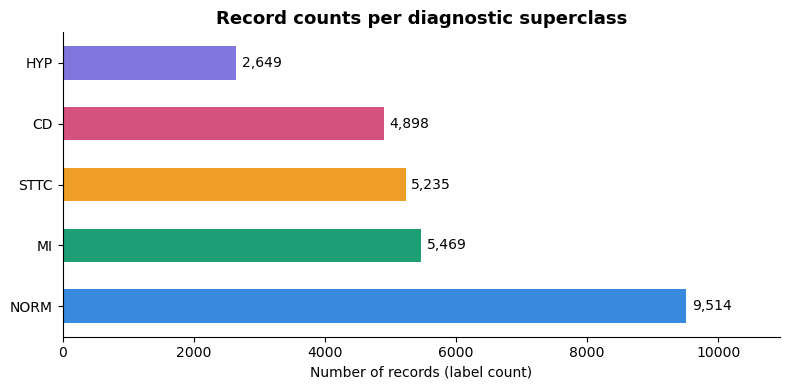

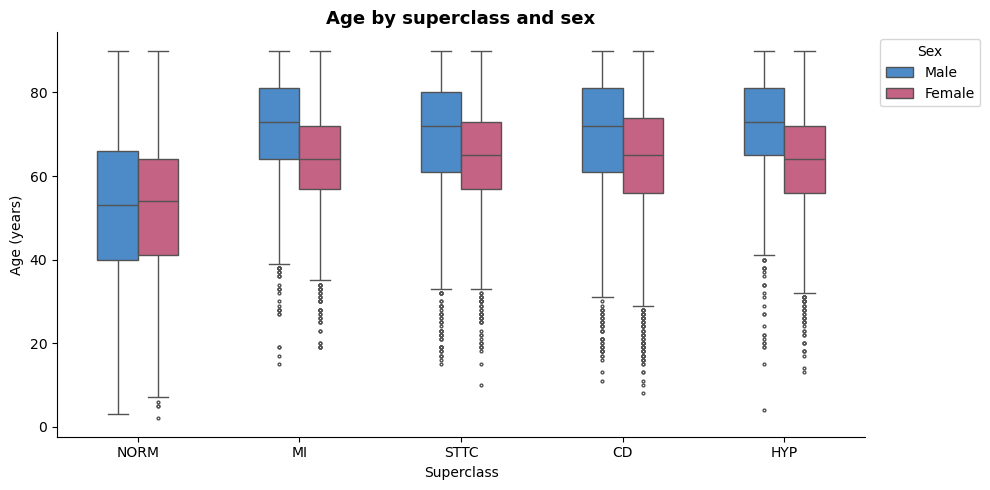

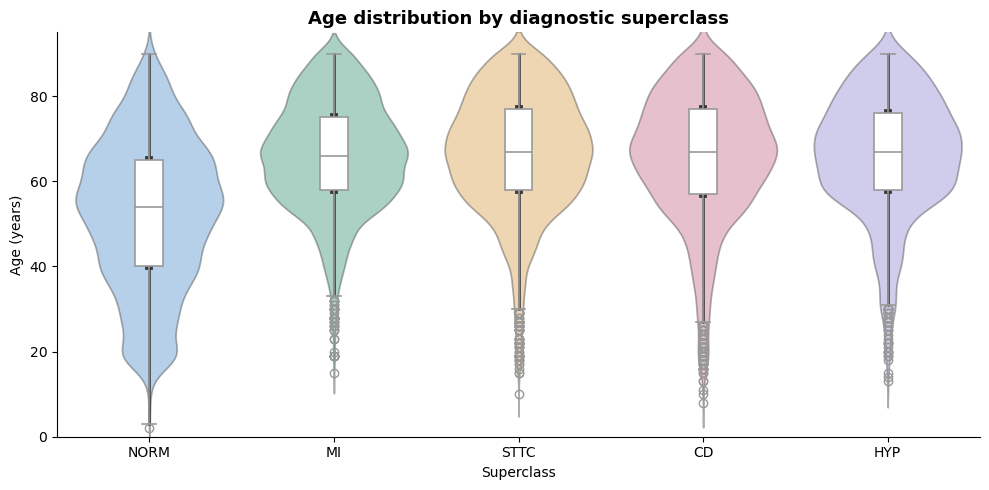

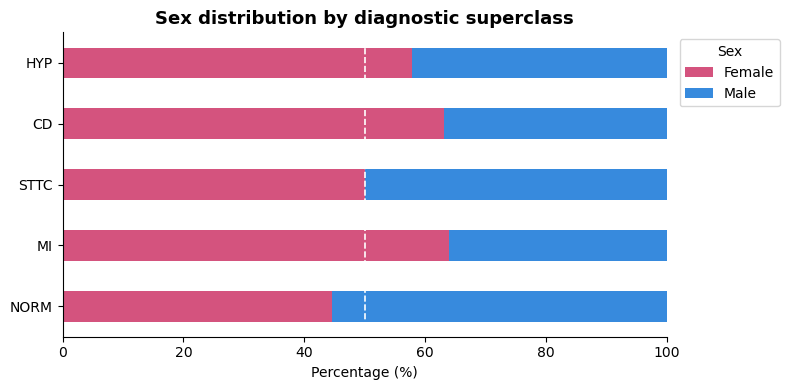

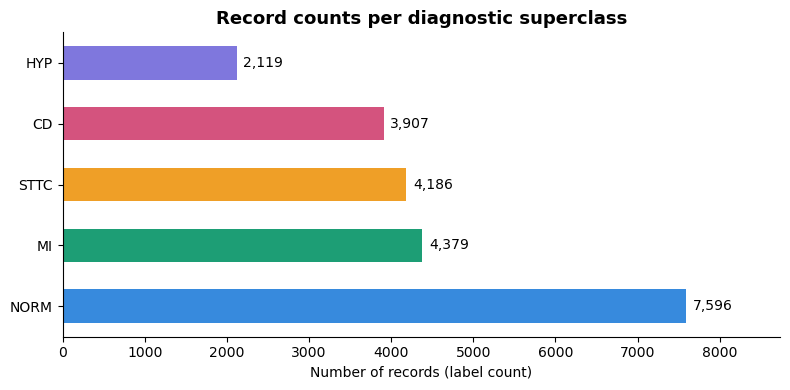

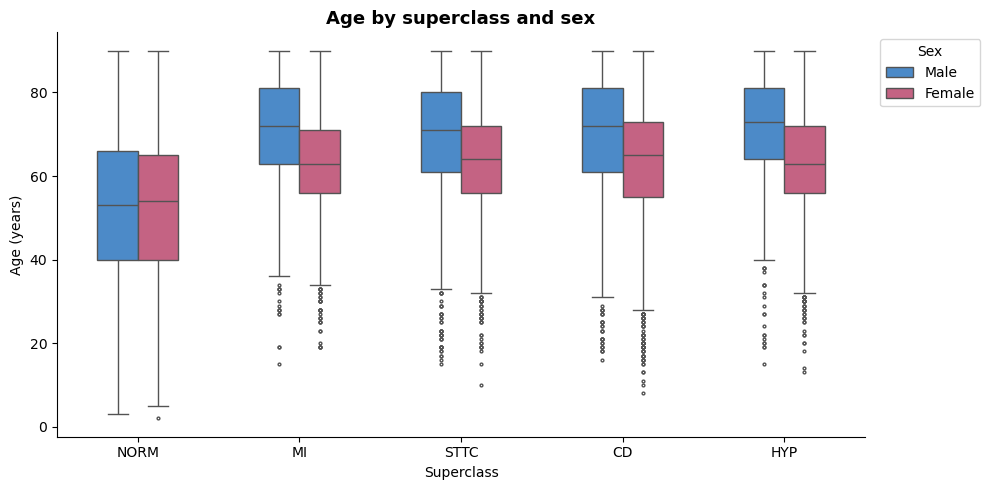

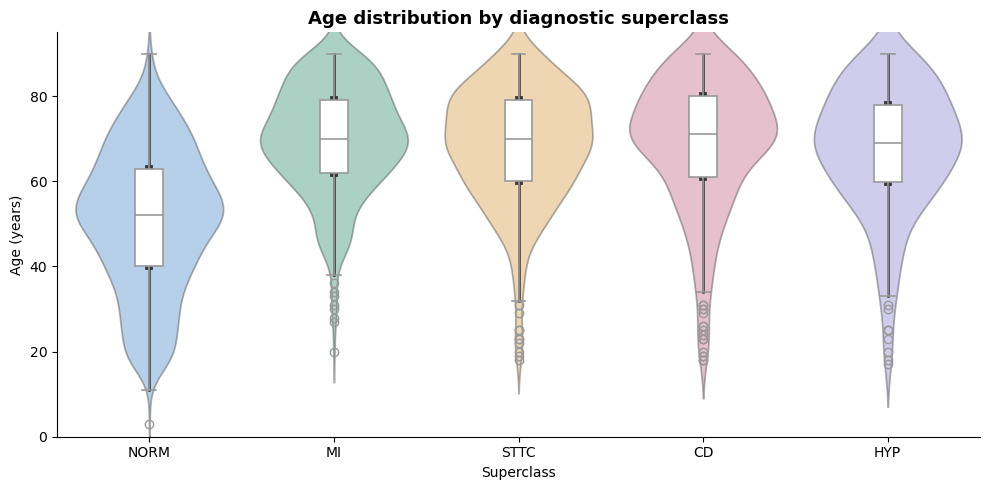

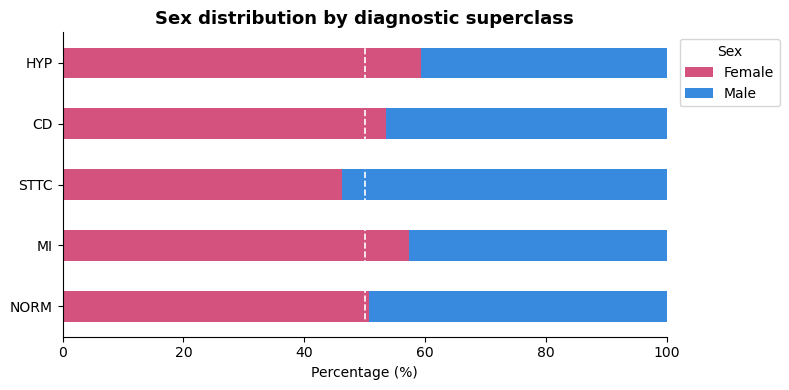

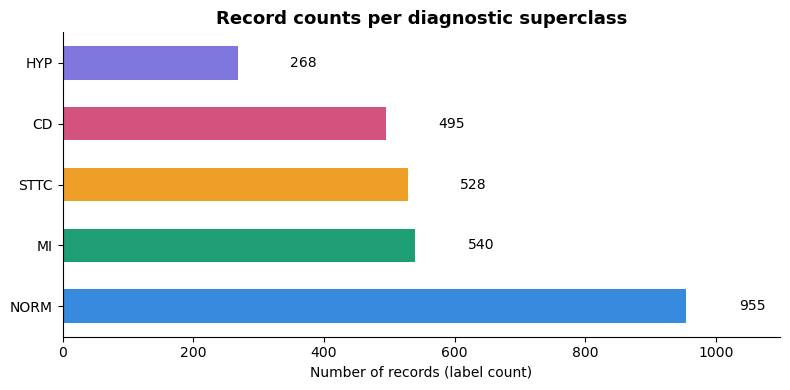

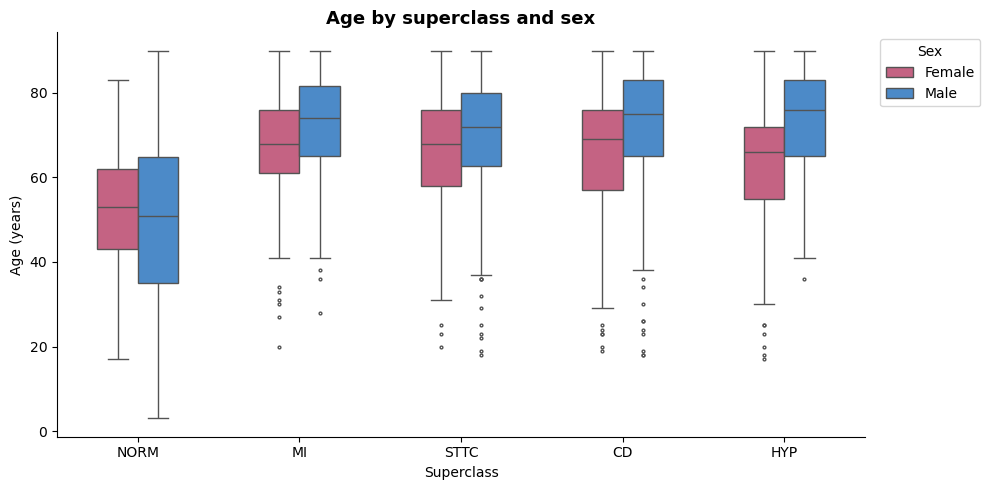

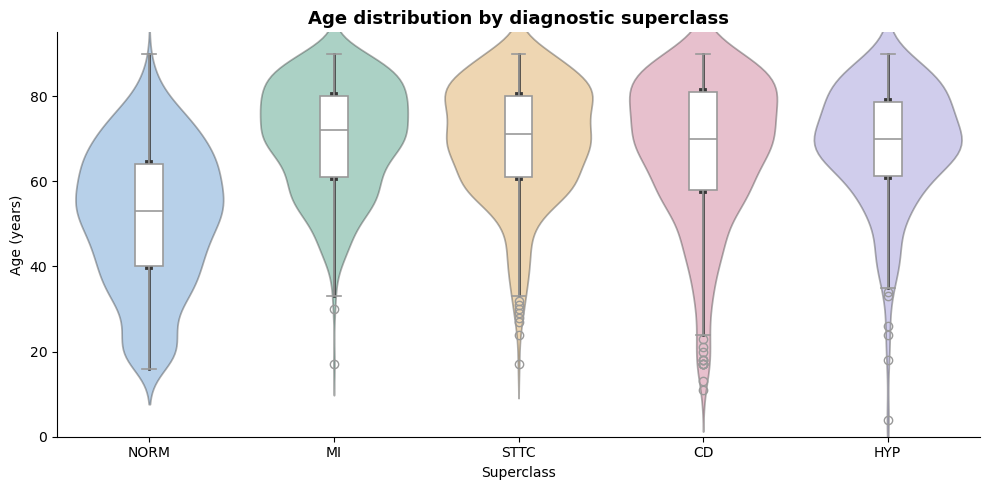

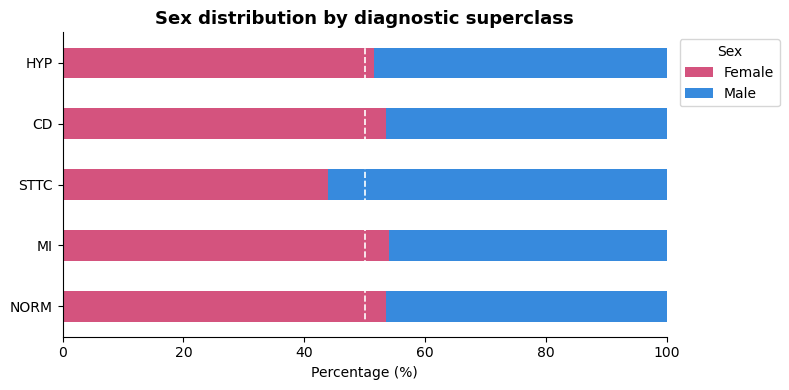

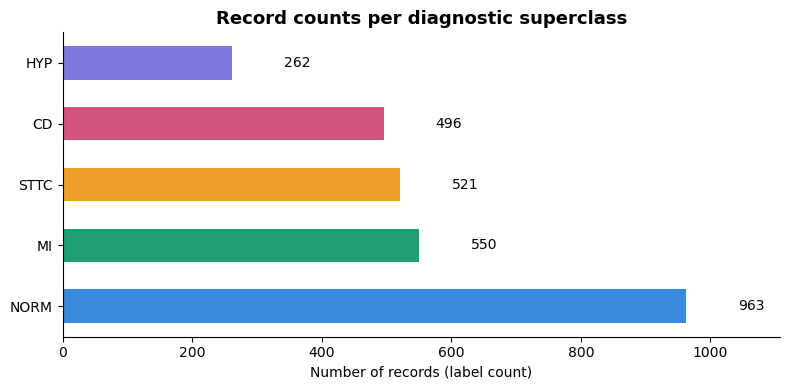

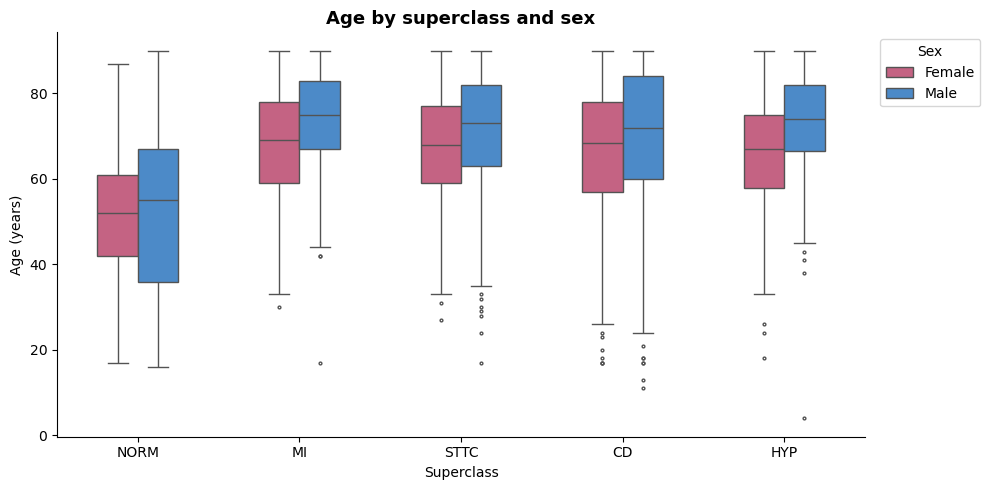

In [40]:
# View the superclass breakdown globally, train, test, val\
# Build split dictionary
split_df = {
    'global': df,
    'train':  df[df['split'] == 'train'],
    'val':    df[df['split'] == 'val'],
    'test':   df[df['split'] == 'test'],
}

# Loop through all splits and display stats
plots_splits = {}
for key, df_split in split_df.items():
    print(f"Split: {key} ({len(df_split):,} records)")
    
    stats, df_exploded = demographics_by_superclass(df_split)
    plots_splits[key]  = plot_demographics_by_superclass(stats, df_exploded)

    print(stats)
    print("_" * 100)
    print("\n")


### Compute Co-occurance 

In [ ]:
from itertools import combinations

# Count how often each pair co-occurs 
pairs = []
for labels in df['superclass']:
    for a, b in combinations(sorted(labels), 2):
        pairs.append((a,b))

# Create dataframe storing co-occurance
cooc = pd.DataFrame(pairs, columns=["A", "B"]).value_counts().reset_index()

# Normalize the co-occurance 0-1
cases = 

In [22]:
cooc

,A,B,count
0,CD,MI,1794
1,HYP,STTC,1509
2,MI,STTC,1339
3,CD,STTC,1066
4,HYP,MI,818
5,CD,HYP,787
6,CD,NORM,415
7,NORM,STTC,33
8,HYP,NORM,5
9,MI,NORM,1


In [21]:
df['n_labels'] = df['superclass'].apply(len)
df['n_labels'].value_counts().sort_index()

n_labels
1    16244
2     4068
3      919
4      157
Name: count, dtype: int64